# Test different simulation parameters
Make simulation look as close as possible to maxs recordings

In [2]:
import sys
import h5py
import numpy as np
import yaml
import matplotlib.pyplot as plt
sys.path.append("../src/utils")
sys.path.append("../src/simulator")
sys.path.append("../src/utils/IEBCS")
import eventIO
import cv2
import simulator
import rotations
import pandas as pd
import logger

In [4]:
sim_output = "../data/simulator/output/testing_sims.hdf5"
snippet_max = "../data/simulator/output/max/snippet_max_2.hdf5"

In [12]:
ev_max = eventIO.load_hdf5(snippet_max)

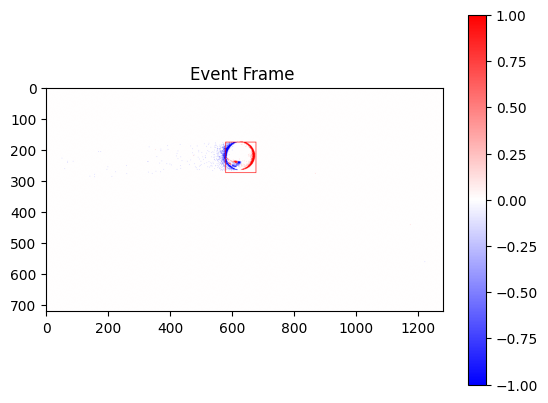

In [25]:
middle = int(ev_max.ts[-1] / 2)
img = np.zeros((720, 1280), dtype=np.float32)
for i in range(len(ev_max.ts)):
    if ev_max.ts[i] >= middle and ev_max.ts[i] <= middle + 500:
        img[ev_max.y[i], ev_max.x[i]] = ev_max.p[i] * 2 - 1
# Define variables for position and size
frame_x, frame_y = 578, 176
frame_size = 100
frame_thickness = 2

# Draw top and bottom borders
img[frame_y:frame_y+frame_thickness, frame_x:frame_x+frame_size] = 1
img[frame_y+frame_size-frame_thickness:frame_y+frame_size, frame_x:frame_x+frame_size] = 1

# Draw left and right borders
img[frame_y:frame_y+frame_size, frame_x:frame_x+frame_thickness] = 1
img[frame_y:frame_y+frame_size, frame_x+frame_size-frame_thickness:frame_x+frame_size] = 1
plt.imshow(img, cmap='bwr', vmin=-1, vmax=1)
plt.title(f"Event Frame ")
plt.colorbar()
plt.show()

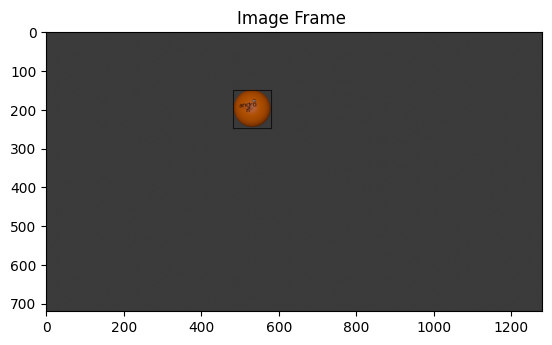

In [41]:
img2 = cv2.imread("../data/simulator/output/temp.png", cv2.IMREAD_COLOR_RGB)

# Define variables for position and size
frame_x, frame_y = 483, 152
frame_size = 100
frame_thickness = 2

# Draw top and bottom borders
img2[frame_y:frame_y+frame_thickness, frame_x:frame_x+frame_size] = 1
img2[frame_y+frame_size-frame_thickness:frame_y+frame_size, frame_x:frame_x+frame_size] = 1

# Draw left and right borders
img2[frame_y:frame_y+frame_size, frame_x:frame_x+frame_thickness] = 1
img2[frame_y:frame_y+frame_size, frame_x+frame_size-frame_thickness:frame_x+frame_size] = 1

plt.imshow(img2)
plt.title(f"Image Frame ")
plt.show()

In [5]:
ev = eventIO.load_hdf5(snippet_max)
ev2 = eventIO.load_hdf5("/data/lkolmar/datasets/topspin_fit_to_max/data/00000/00000_events.hdf5")

In [6]:
eventIO.print_event_info(ev)
eventIO.print_event_info(ev2)

Event Buffer Information:
Number of events: 935706
Time range [us]: 0 - 124999
Total time [s]: 0.124999
Recalculated RPS (using 2.0 total rounds): 16.00 RPS
Resolution: 1251 x 719
Polarity values: [0 1]
Events per pixel: 1.04
Sample events (first 10):
Event 0: t=0, x=60, y=274, p=1
Event 1: t=0, x=60, y=250, p=1
Event 2: t=0, x=57, y=292, p=1
Event 3: t=1, x=62, y=258, p=1
Event 4: t=1, x=65, y=274, p=1
Event 5: t=2, x=55, y=284, p=1
Event 6: t=2, x=51, y=236, p=1
Event 7: t=2, x=50, y=296, p=1
Event 8: t=2, x=58, y=289, p=1
Event 9: t=3, x=54, y=295, p=1
Event Buffer Information:
Number of events: 1118084
Time range [us]: 7 - 184123
Total time [s]: 0.184116
Recalculated RPS (using 2.0 total rounds): 10.86 RPS
Resolution: 1280 x 720
Polarity values: [0 1]
Events per pixel: 1.21
Sample events (first 10):
Event 0: t=7, x=1219, y=288, p=0
Event 1: t=16, x=1062, y=238, p=0
Event 2: t=21, x=461, y=83, p=1
Event 3: t=24, x=543, y=128, p=1
Event 4: t=28, x=874, y=223, p=0
Event 5: t=31, x=555

In [3]:
ev = eventIO.load_hdf5("/data/lkolmar/datasets/topspin_fit_to_max/data/01627/01627_events.hdf5")

In [9]:
eventIO.print_event_info(ev)
eventIO.create_video(ev, "../data/simulator/output/max/second_run.avi", resolution=(1280, 720), fps=30.0, tw=280)

Event Buffer Information:
Number of events: 1120283
Time range [us]: 1 - 174975
Total time [s]: 0.174974
Recalculated RPS (using 2.0 total rounds): 11.43 RPS
Resolution: 1280 x 720
Polarity values: [0 1]
Events per pixel: 1.22
Sample events (first 10):
Event 0: t=1, x=543, y=103, p=1
Event 1: t=4, x=1118, y=500, p=0
Event 2: t=6, x=376, y=332, p=0
Event 3: t=10, x=1194, y=526, p=0
Event 4: t=10, x=866, y=340, p=1
Event 5: t=12, x=1045, y=608, p=0
Event 6: t=17, x=1241, y=400, p=1
Event 7: t=18, x=148, y=10, p=0
Event 8: t=25, x=274, y=195, p=0
Event 9: t=27, x=737, y=687, p=0
